# Import Libraries

In [7]:
import sys
print(sys.version)

3.13.7 (tags/v3.13.7:bcee1c3, Aug 14 2025, 14:15:11) [MSC v.1944 64 bit (AMD64)]


In [8]:
#!pip install textblob==0.17.1
from textblob import TextBlob

In [10]:
# Data manipulation
#!pip install vaderSentiment
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text processing
import re
import nltk
from nltk.corpus import stopwords

# Lexicons
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\cody_\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# Load Dataset

In [12]:

file_path = file_path = "Gift_Cards_5.json"
df = pd.read_json(file_path, lines=True)

df = pd.read_json(file_path, lines=True)

# Basic Information

In [13]:
print("Total Reviews:", len(df))
print("Average Rating:", df['overall'].mean())

df.info()
df.describe()

Total Reviews: 2972
Average Rating: 4.885262449528937
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2972 entries, 0 to 2971
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   overall         2972 non-null   int64  
 1   verified        2972 non-null   bool   
 2   reviewTime      2972 non-null   object 
 3   reviewerID      2972 non-null   object 
 4   asin            2972 non-null   object 
 5   style           864 non-null    object 
 6   reviewerName    2972 non-null   object 
 7   reviewText      2966 non-null   object 
 8   summary         2972 non-null   object 
 9   unixReviewTime  2972 non-null   int64  
 10  vote            208 non-null    float64
 11  image           12 non-null     object 
dtypes: bool(1), float64(1), int64(2), object(8)
memory usage: 258.4+ KB


,overall,unixReviewTime,vote
count,2972.000000,2.972000e+03,208.000000
mean,4.885262,1.476136e+09,5.158654
std,0.484660,3.379616e+07,7.366121
min,1.000000,1.327968e+09,2.000000
25%,5.000000,1.454890e+09,2.000000
50%,5.000000,1.482710e+09,3.000000
75%,5.000000,1.500271e+09,5.000000
max,5.000000,1.534896e+09,60.000000


# Rating Distribution

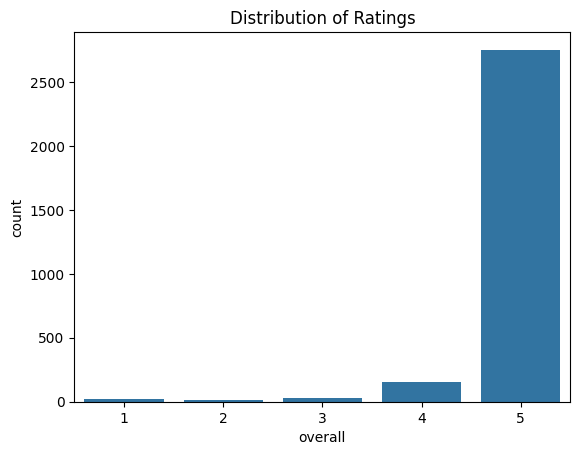

In [14]:
sns.countplot(x='overall', data=df)
plt.title("Distribution of Ratings")
plt.show()

# Reviews Per Product

count    148.000000
mean      20.081081
std       19.359300
min        4.000000
25%        8.000000
50%       12.000000
75%       26.250000
max       94.000000
dtype: float64


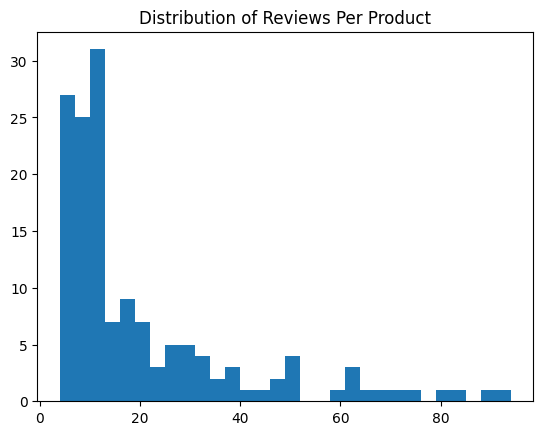

In [15]:
reviews_per_product = df.groupby('asin').size()

print(reviews_per_product.describe())

plt.hist(reviews_per_product, bins=30)
plt.title("Distribution of Reviews Per Product")
plt.show()

# Reviews Per User

count    458.000000
mean       6.489083
std        2.710885
min        5.000000
25%        5.000000
50%        6.000000
75%        7.000000
max       32.000000
dtype: float64


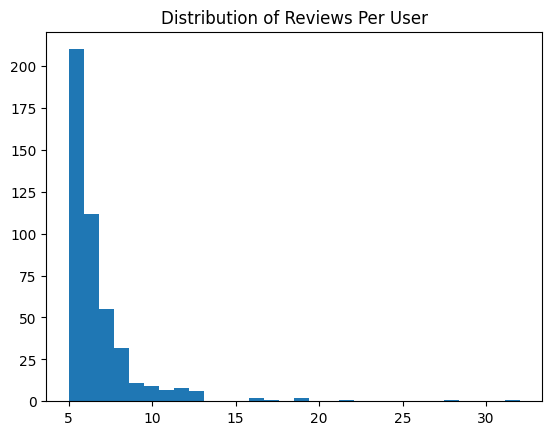

In [16]:
reviews_per_user = df.groupby('reviewerID').size()

print(reviews_per_user.describe())

plt.hist(reviews_per_user, bins=30)
plt.title("Distribution of Reviews Per User")
plt.show()

# Review Length Analysis

count    2966.000000
mean       67.467296
std       131.120601
min         2.000000
25%        12.000000
50%        29.000000
75%        72.000000
max      2409.000000
Name: review_length, dtype: float64


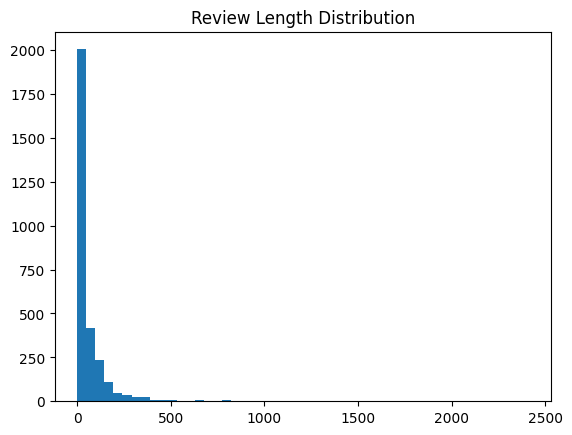

In [17]:
df['review_length'] = df['reviewText'].str.len()

print(df['review_length'].describe())

plt.hist(df['review_length'], bins=50)
plt.title("Review Length Distribution")
plt.show()

# Check Duplicates

In [ ]:
print("Duplicate Rows:", df.select_dtypes(exclude=['object']).duplicated().sum())

key_cols = ["reviewerID", "asin", "reviewText", "unixReviewTime"]
dupe_key = df.duplicated(subset=key_cols).sum()
print("Duplicate reviews by (reviewerID, asin, reviewText, unixReviewTime):", dupe_key)

dupe_key_all = df.duplicated(subset=key_cols, keep=False).sum()
print("All rows involved in duplicates:", dupe_key_all)


Duplicate Rows: 830
Duplicate reviews by (reviewerID, asin, reviewText, unixReviewTime): 0
All rows involved in duplicates (keep=False): 0


## TEXT PRE-PROCESSING

### Label Sentiment

In [19]:
def label_sentiment(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

df['sentiment'] = df['overall'].apply(label_sentiment)

df['sentiment'].value_counts()

sentiment
Positive    2906
Negative      33
Neutral       33
Name: count, dtype: int64

# Clean Text

In [20]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df['cleaned_text'] = df['reviewText'].astype(str).apply(clean_text)

df[['reviewText', 'cleaned_text']].head()

,reviewText,cleaned_text
0,Another great gift.,another great gift
1,Gift card for my daughter,gift card daughter
2,Nice present,nice present
3,My niece loved this birthday greeting/gift card.,niece loved birthday greetinggift card
4,fine as a gift.,fine gift


 # Select 1000 Random Reviews

In [21]:
df_sample = df.sample(n=1000, random_state=42)

df_sample.shape

(1000, 15)

# MODEL 1 — VADER


In [22]:
analyzer = SentimentIntensityAnalyzer()

def vader_sentiment(text):
    score = analyzer.polarity_scores(text)['compound']
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df_sample['vader_prediction'] = df_sample['cleaned_text'].apply(vader_sentiment)

df_sample[['sentiment','vader_prediction']].head()

,sentiment,vader_prediction
2400,Positive,Positive
2862,Positive,Positive
2167,Positive,Positive
507,Positive,Positive
2839,Positive,Positive


# MODEL 2 — TextBlob

In [23]:
def textblob_sentiment(text):
    score = TextBlob(text).sentiment.polarity
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df_sample['textblob_prediction'] = df_sample['cleaned_text'].apply(textblob_sentiment)

df_sample[['sentiment','textblob_prediction']].head()

,sentiment,textblob_prediction
2400,Positive,Positive
2862,Positive,Positive
2167,Positive,Positive
507,Positive,Positive
2839,Positive,Positive


# Accuracy

In [24]:
print("VADER Accuracy:", accuracy_score(df_sample['sentiment'], df_sample['vader_prediction']))
print("TextBlob Accuracy:", accuracy_score(df_sample['sentiment'], df_sample['textblob_prediction']))

VADER Accuracy: 0.853
TextBlob Accuracy: 0.736


# Classification Reports

In [25]:
print("VADER REPORT")
print(classification_report(df_sample['sentiment'], df_sample['vader_prediction']))

print("TEXTBLOB REPORT")
print(classification_report(df_sample['sentiment'], df_sample['textblob_prediction']))

VADER REPORT
              precision    recall  f1-score   support

    Negative       0.23      0.46      0.31        13
     Neutral       0.00      0.00      0.00        10
    Positive       0.98      0.87      0.92       977

    accuracy                           0.85      1000
   macro avg       0.40      0.44      0.41      1000
weighted avg       0.96      0.85      0.90      1000

TEXTBLOB REPORT
              precision    recall  f1-score   support

    Negative       0.11      0.31      0.16        13
     Neutral       0.01      0.30      0.03        10
    Positive       0.98      0.75      0.85       977

    accuracy                           0.74      1000
   macro avg       0.37      0.45      0.35      1000
weighted avg       0.96      0.74      0.83      1000



# Confusion Matrix

In [26]:
print("VADER Confusion Matrix")
print(confusion_matrix(df_sample['sentiment'], df_sample['vader_prediction']))

print("TEXTBLOB Confusion Matrix")
print(confusion_matrix(df_sample['sentiment'], df_sample['textblob_prediction']))

VADER Confusion Matrix
[[  6   0   7]
 [  1   0   9]
 [ 19 111 847]]
TEXTBLOB Confusion Matrix
[[  4   3   6]
 [  1   3   6]
 [ 31 217 729]]
